# Análisis integral de calidad en bibliotecas públicas de Bogotá

Este notebook consolida todos los archivos de `Datos/`, calcula indicadores de calidad (luz, ruido, WiFi), evalúa cumplimiento normativo y exporta resultados para el informe LaTeX.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

BASE = Path.cwd()
ROOT = BASE if (BASE / "scripts").exists() else BASE.parent
sys.path.insert(0, str(ROOT))

from scripts.analisis_bibliotecas import load_data, export_tables, export_figures, export_conclusions, OutputPaths

OUT = OutputPaths(figuras=ROOT / "Informe" / "figuras", tablas=ROOT / "Informe" / "tablas")

sns.set_theme(style="whitegrid")

/home/ingeniero/Desktop/Informe-sobre-calidad-de-bibliotecas-publicas-en-Bogota/scripts/analisis_bibliotecas.py:501: SyntaxWarning: invalid escape sequence '\%'
  Las bibliotecas de mayor desempeño ponderado fueron: """ + "; ".join([f"{r['Biblioteca']} ({r['indice_ponderado']:.1f})" for _, r in top.iterrows()]) + ". " + """Las de menor desempeño fueron: """ + "; ".join([f"{r['Biblioteca']} ({r['indice_ponderado']:.1f})" for _, r in bottom.iterrows()]) + "."
/home/ingeniero/Desktop/Informe-sobre-calidad-de-bibliotecas-publicas-en-Bogota/scripts/analisis_bibliotecas.py:501: SyntaxWarning: invalid escape sequence '\%'
  Las bibliotecas de mayor desempeño ponderado fueron: """ + "; ".join([f"{r['Biblioteca']} ({r['indice_ponderado']:.1f})" for _, r in top.iterrows()]) + ". " + """Las de menor desempeño fueron: """ + "; ".join([f"{r['Biblioteca']} ({r['indice_ponderado']:.1f})" for _, r in bottom.iterrows()]) + "."
/home/ingeniero/Desktop/Informe-sobre-calidad-de-bibliotecas-publicas-en-Bog

## 1. Carga y limpieza de datos

In [2]:
df = load_data(ROOT / "Datos")
print(f"Registros válidos: {len(df)}")
print(f"Bibliotecas: {df['Biblioteca'].nunique()}")
print(f"Localidades: {df['Localidad'].astype(str).nunique()}")
df.head(3)

Registros válidos: 1420
Bibliotecas: 17
Localidades: 13


/home/ingeniero/Desktop/Informe-sobre-calidad-de-bibliotecas-publicas-en-Bogota/scripts/analisis_bibliotecas.py:143: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data["Hora_dt"] = pd.to_datetime(data["Hora"].astype(str), errors="coerce")


,N°,Teléfono (marca/modelo),App Luz,App Sonido,Apps WiFi,Fecha,Hora,Biblioteca,Localidad,Dirección/Referencia,...,archivo_fuente,hoja_fuente,Hora_dt,Franja,Lux_umbral,Cumple_Luz,Cumple_Ruido,Cumple_WiFi,Indice_Compuesto,Indice_Ponderado
0,1,Samsung Galaxy S21,Lux Light Meter,Decibel X,WiFi Analyzer + Speedtest,2026-02-15,09:00:00,Luis Ángel Arango,La Candelaria,Calle 11 #4-14,...,Angelica Maria Rodriguez Hernandez.xlsx,Registro,2026-04-14 09:00:00,Manana,500,True,True,True,100.0,100.0
1,2,Samsung Galaxy S21,Lux Light Meter,Decibel X,WiFi Analyzer + Speedtest,2026-02-15,09:30:00,Luis Ángel Arango,La Candelaria,Calle 11 #4-14,...,Angelica Maria Rodriguez Hernandez.xlsx,Registro,2026-04-14 09:30:00,Manana,500,True,True,True,100.0,100.0
2,3,Samsung Galaxy S21,Lux Light Meter,Decibel X,WiFi Analyzer + Speedtest,2026-02-15,10:00:00,Luis Ángel Arango,La Candelaria,Calle 11 #4-14,...,Angelica Maria Rodriguez Hernandez.xlsx,Registro,2026-04-14 10:00:00,Manana,500,True,True,True,100.0,100.0


## 2. Exportación de tablas y figuras para el informe

In [3]:
tables = export_tables(df, OUT)
export_figures(df, OUT)
export_conclusions(df, tables, OUT)
list((ROOT / "Informe" / "tablas").glob("*.csv"))[:5]

[PosixPath('/home/ingeniero/Desktop/Informe-sobre-calidad-de-bibliotecas-publicas-en-Bogota/Informe/tablas/intervalos_confianza.csv'),
 PosixPath('/home/ingeniero/Desktop/Informe-sobre-calidad-de-bibliotecas-publicas-en-Bogota/Informe/tablas/datos_consolidados.csv'),
 PosixPath('/home/ingeniero/Desktop/Informe-sobre-calidad-de-bibliotecas-publicas-en-Bogota/Informe/tablas/posthoc_significativos.csv'),
 PosixPath('/home/ingeniero/Desktop/Informe-sobre-calidad-de-bibliotecas-publicas-en-Bogota/Informe/tablas/efecto_kruskal.csv'),
 PosixPath('/home/ingeniero/Desktop/Informe-sobre-calidad-de-bibliotecas-publicas-en-Bogota/Informe/tablas/outliers_resumen.csv')]

## 3. Ranking de cumplimiento

In [4]:
tables["cumplimiento"].head(10)

,Biblioteca,cumplimiento_luz,cumplimiento_ruido,cumplimiento_wifi,indice_compuesto,indice_ponderado
0,Biblioteca Luis Angel Arango,96.00,100.00,40.00,78.67,86.40
1,Luis Ángel Arango,92.59,51.85,100.00,81.48,77.78
2,Biblioteca Casa Gómez Campuzano,100.00,10.00,100.00,70.00,64.00
3,Virgilio Barco Bibloteca,100.00,0.00,99.00,66.33,59.80
4,Parque vertical CEFE,96.30,0.00,100.00,65.43,58.52
5,Julio Mario Santo Domingo,72.00,6.00,100.00,59.33,51.20
6,Biblioteca el Tintal,38.78,67.35,40.82,48.98,50.61
7,Biblioteca Julio Mario Santo Domingo,30.00,44.00,91.00,55.00,47.80
8,Biblioteca Pública Bosa,63.33,0.00,100.00,54.44,45.33
9,FRANCISCO JOSE DE CALDAS,50.00,16.67,93.33,53.33,45.33


## 4. Pruebas estadísticas (Kruskal-Wallis)

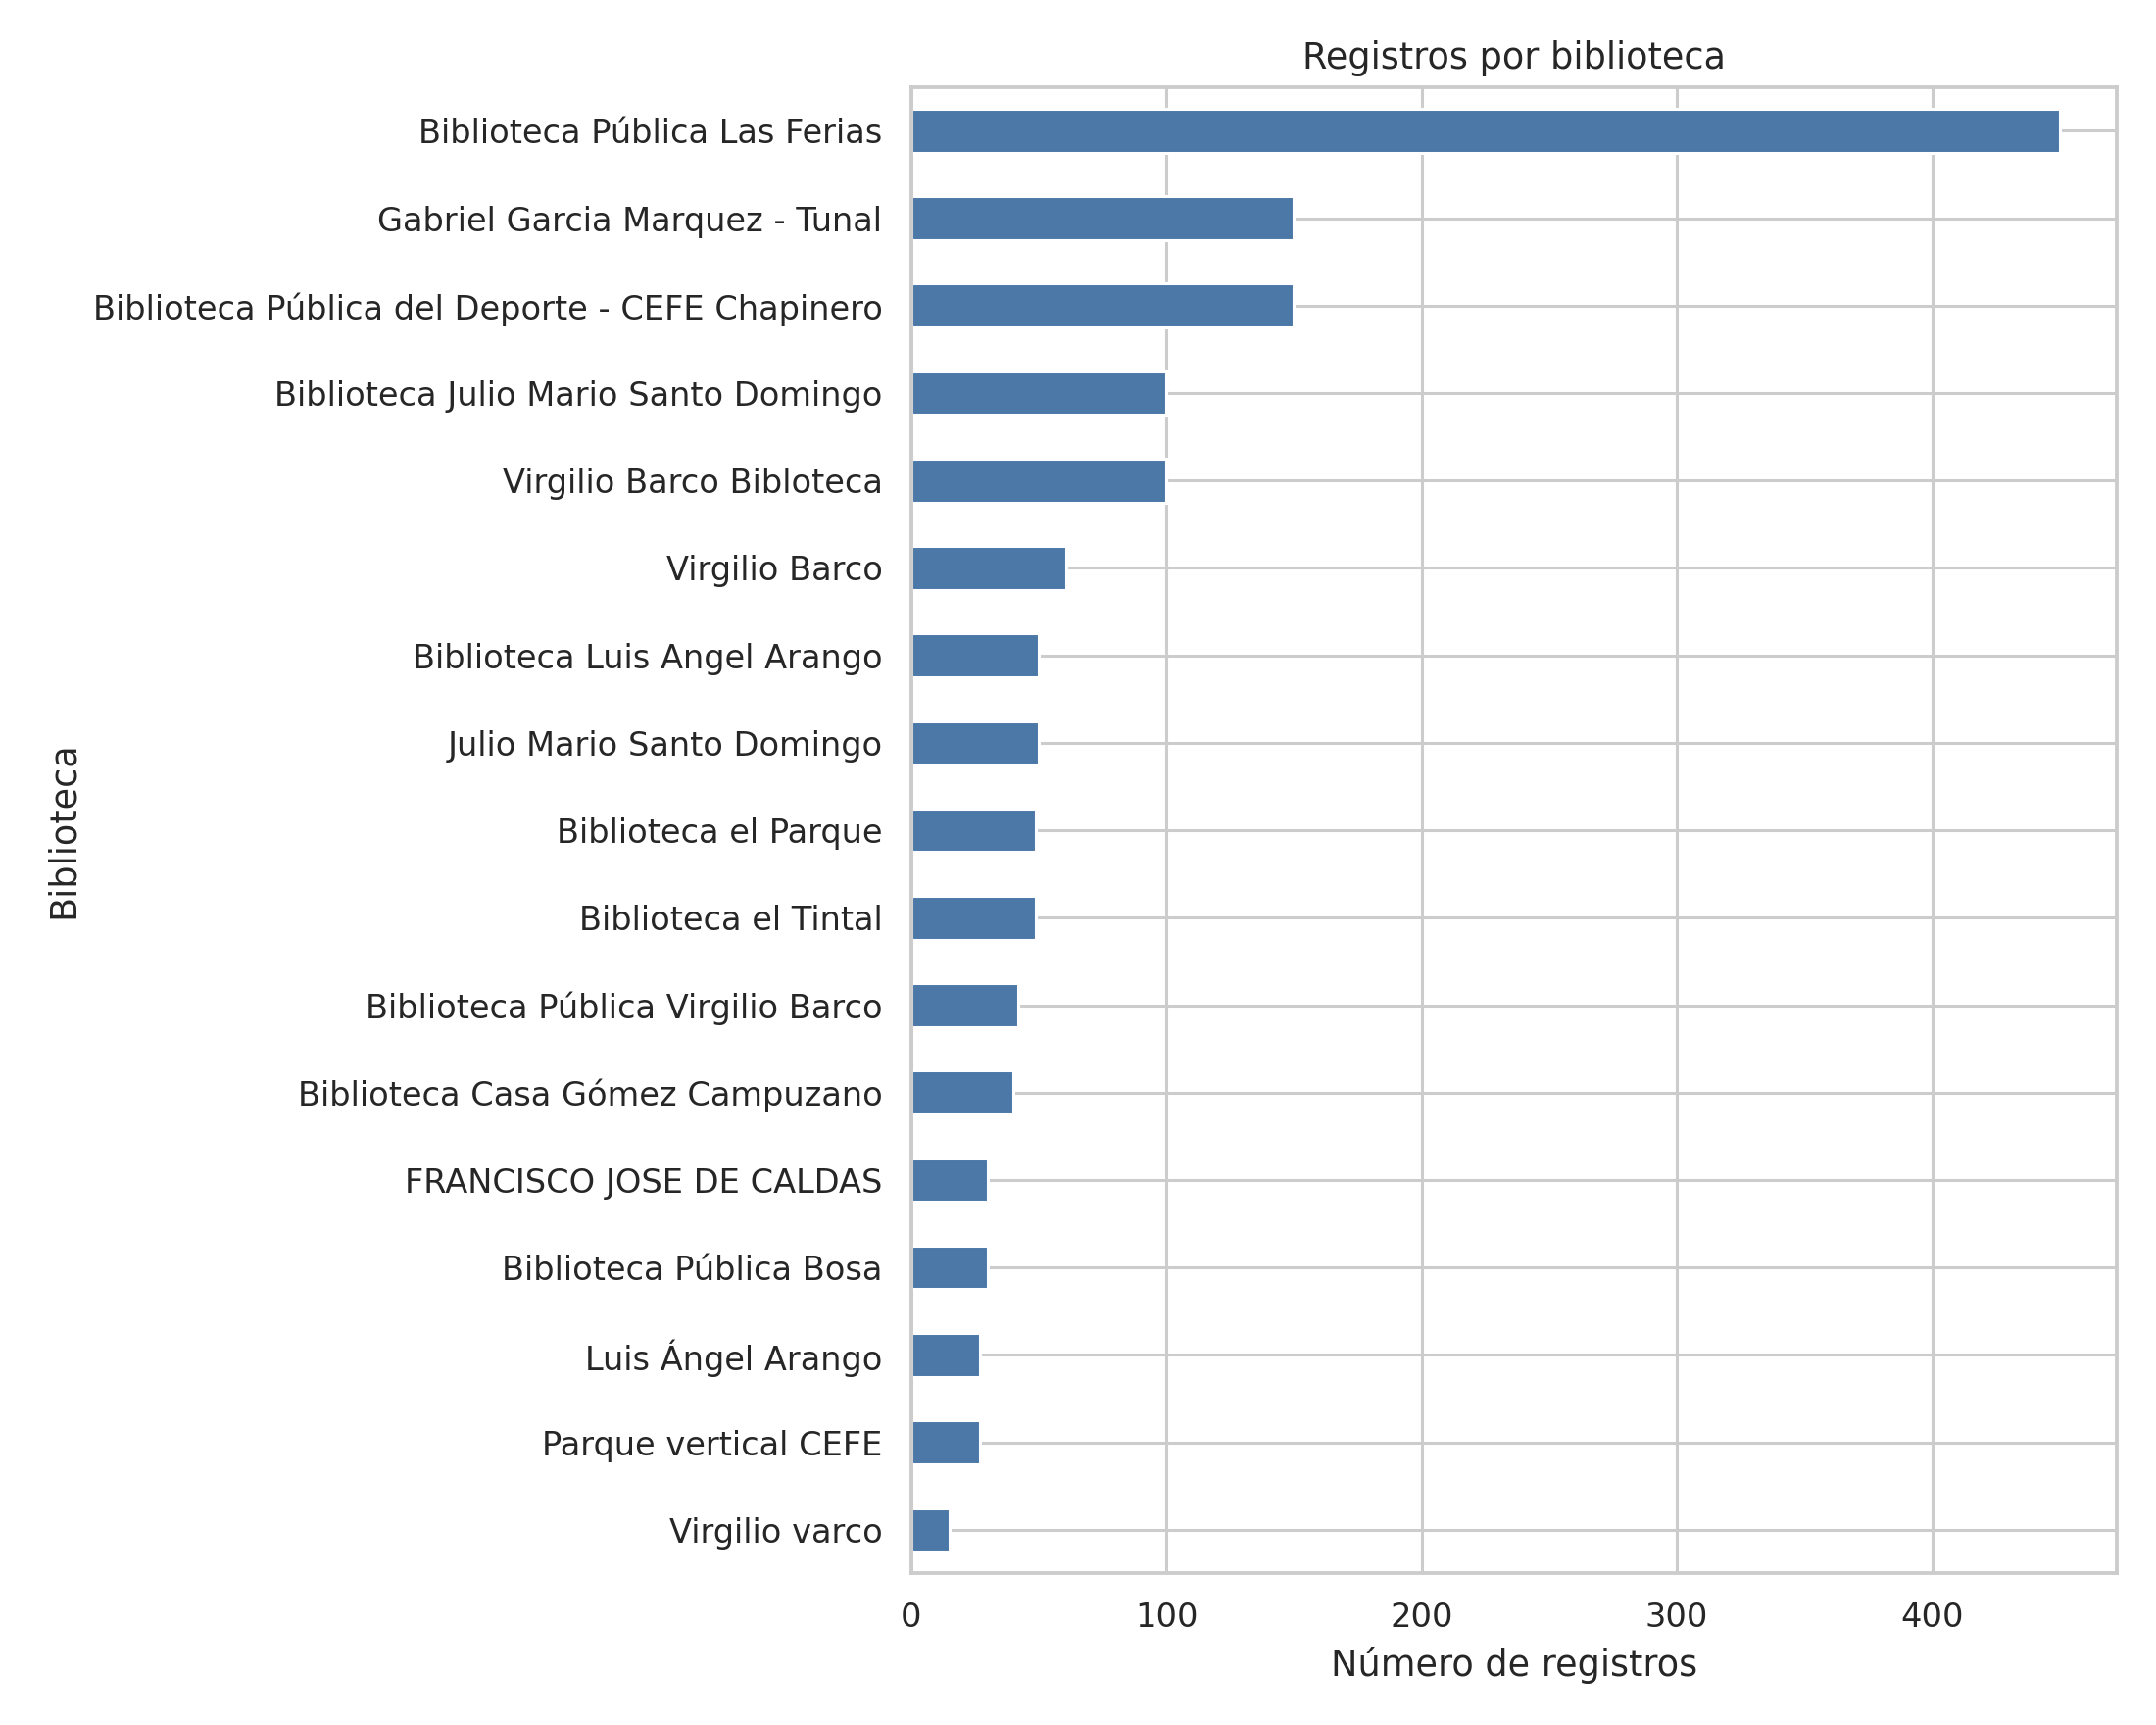

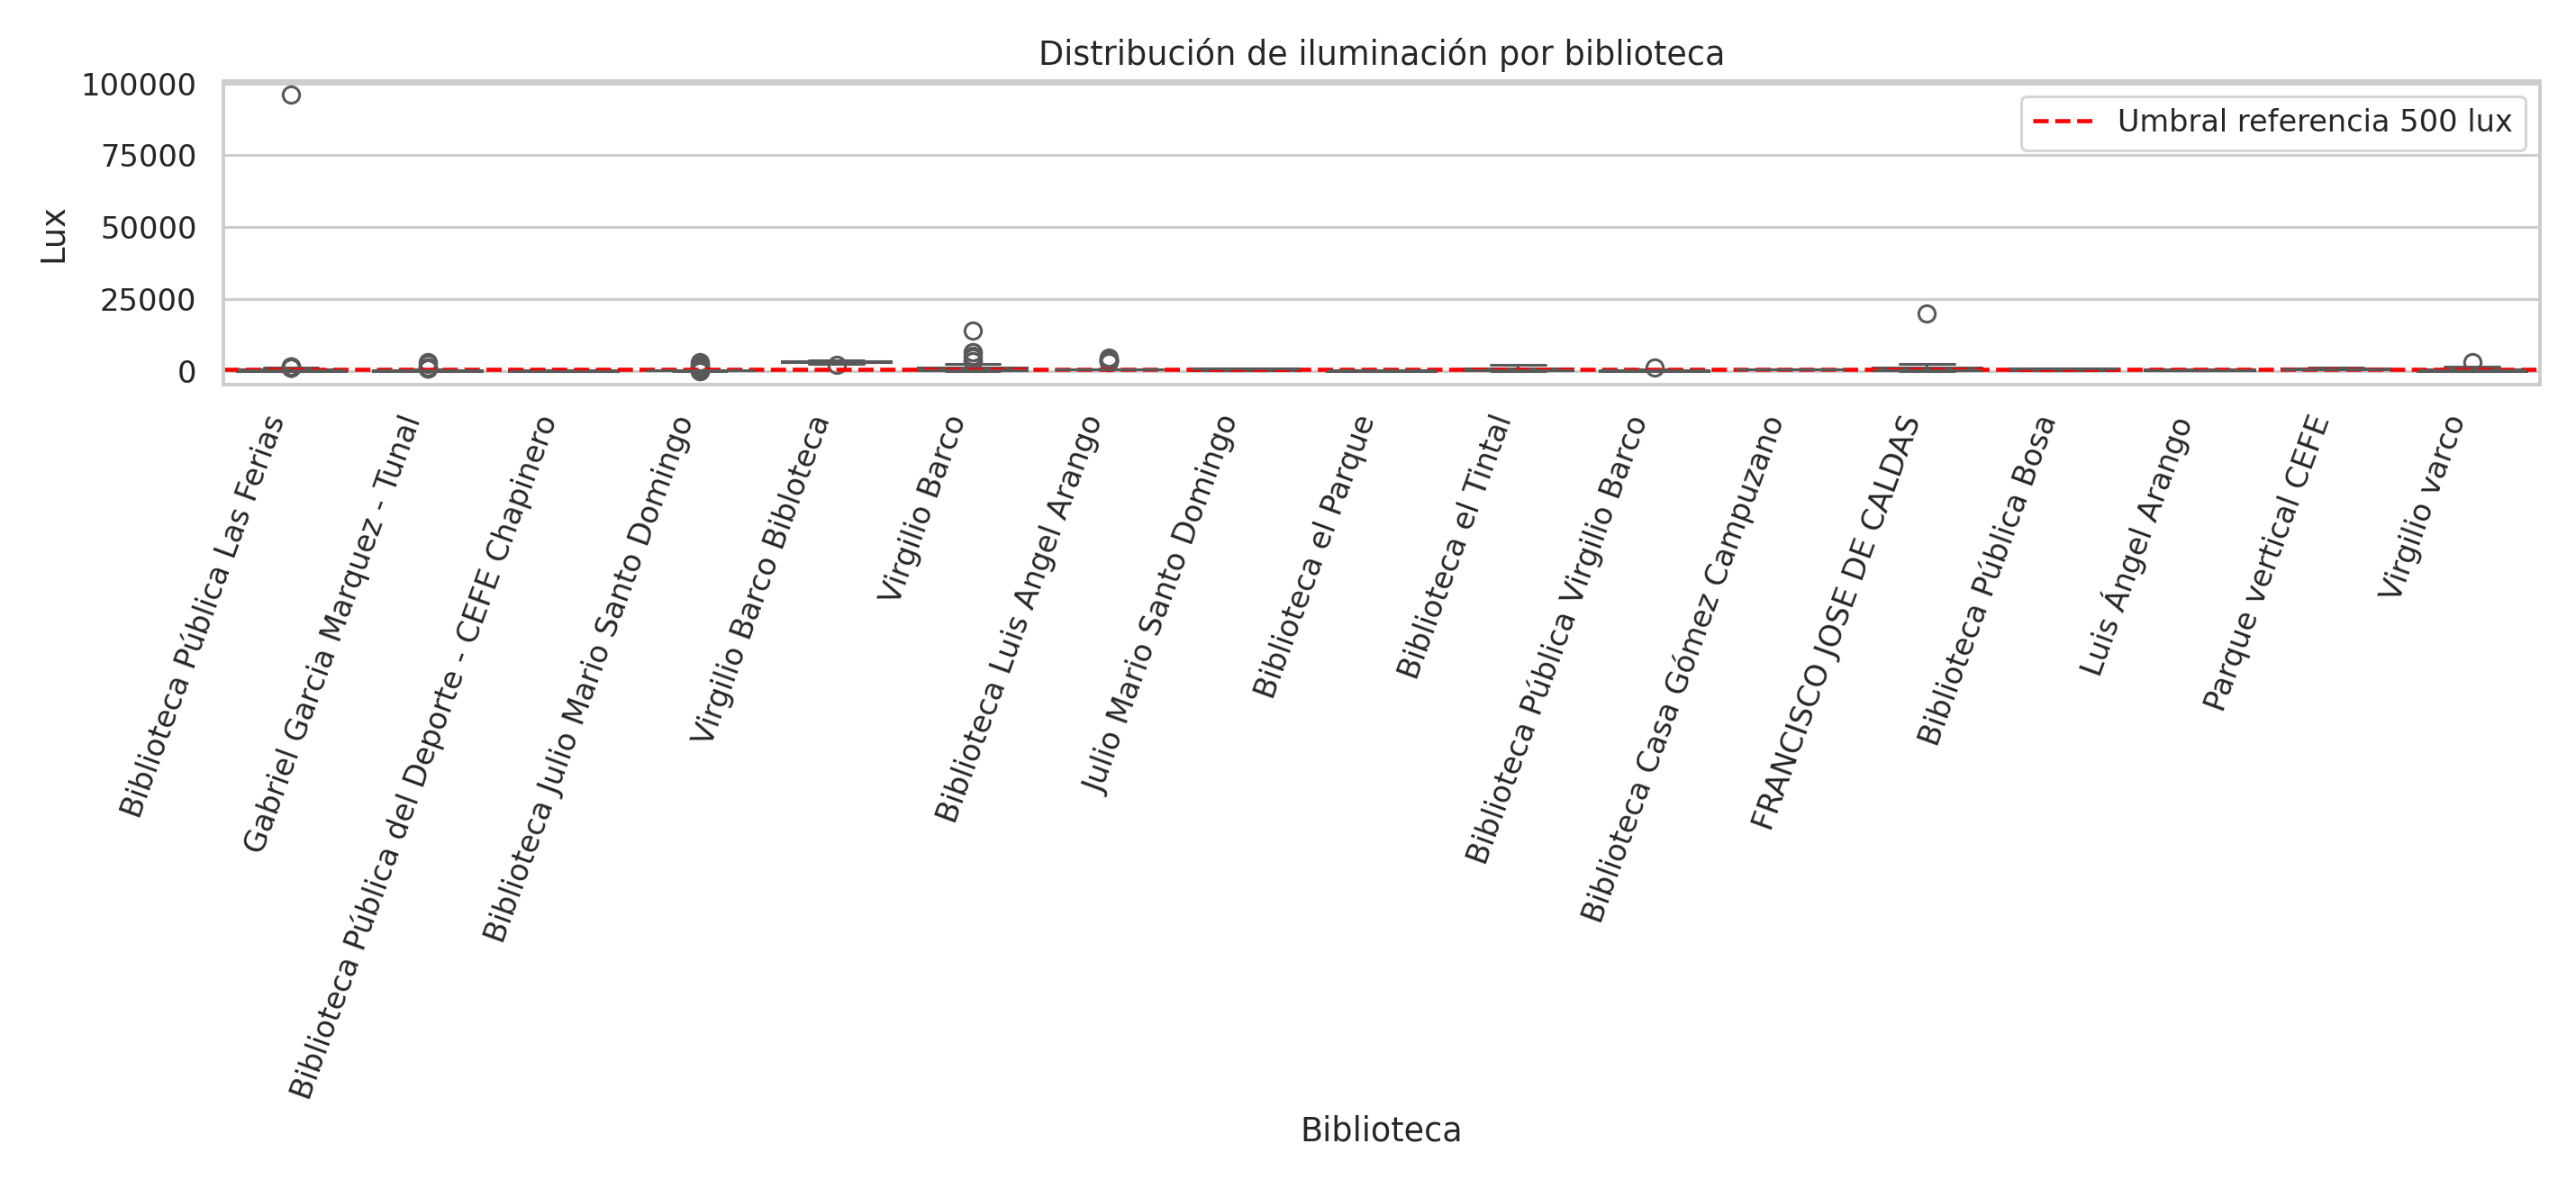

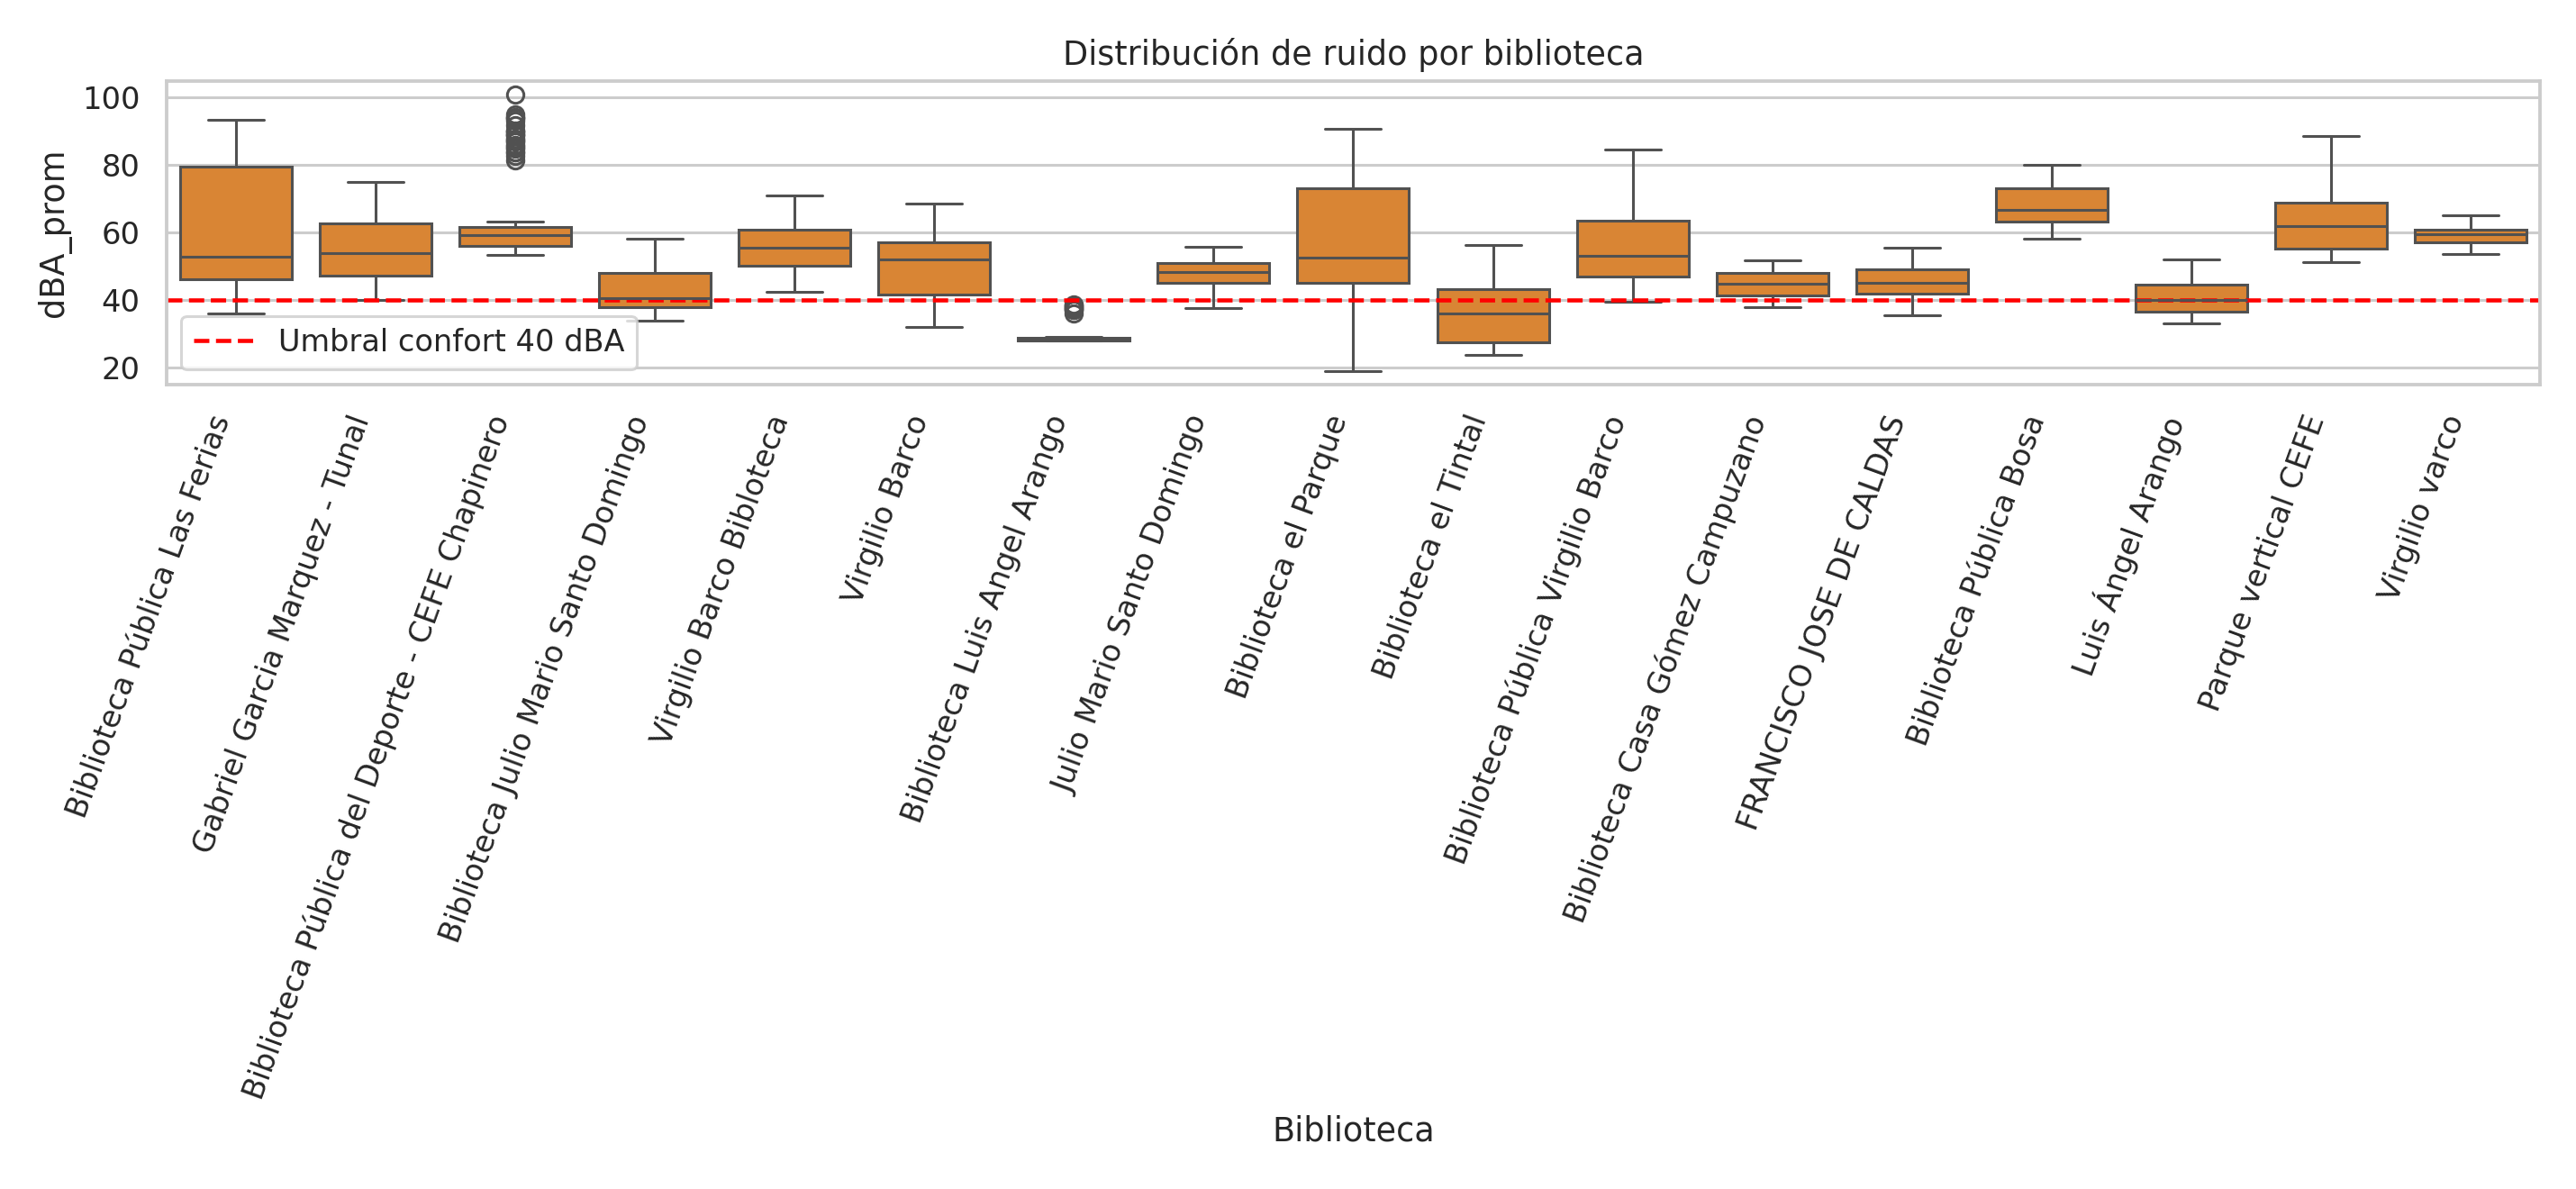

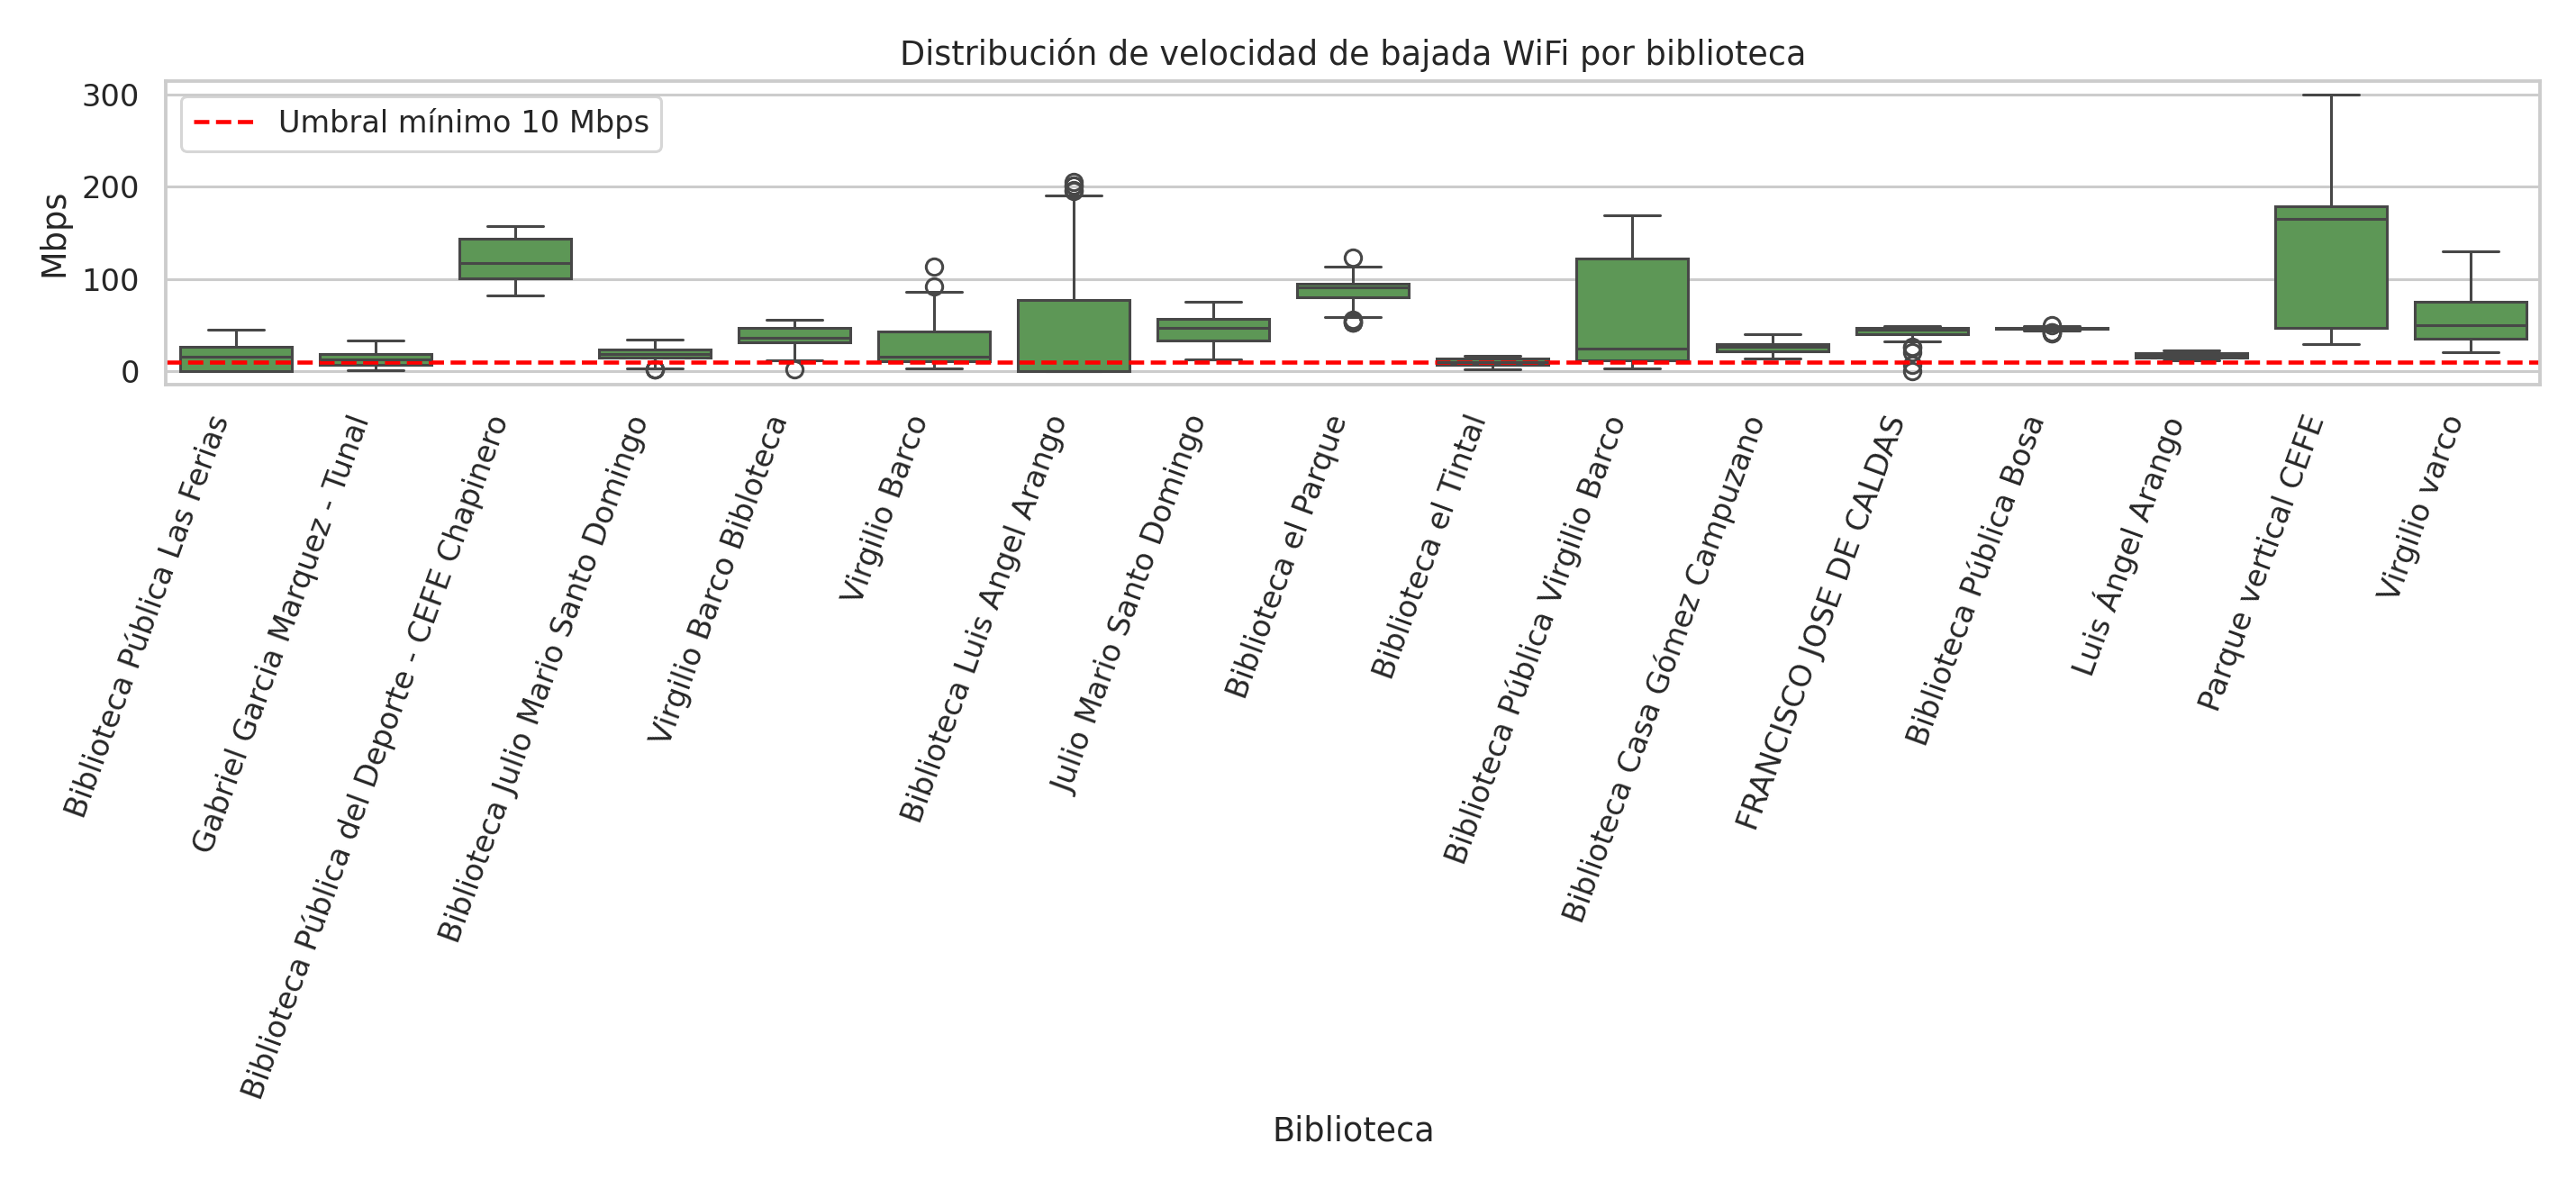

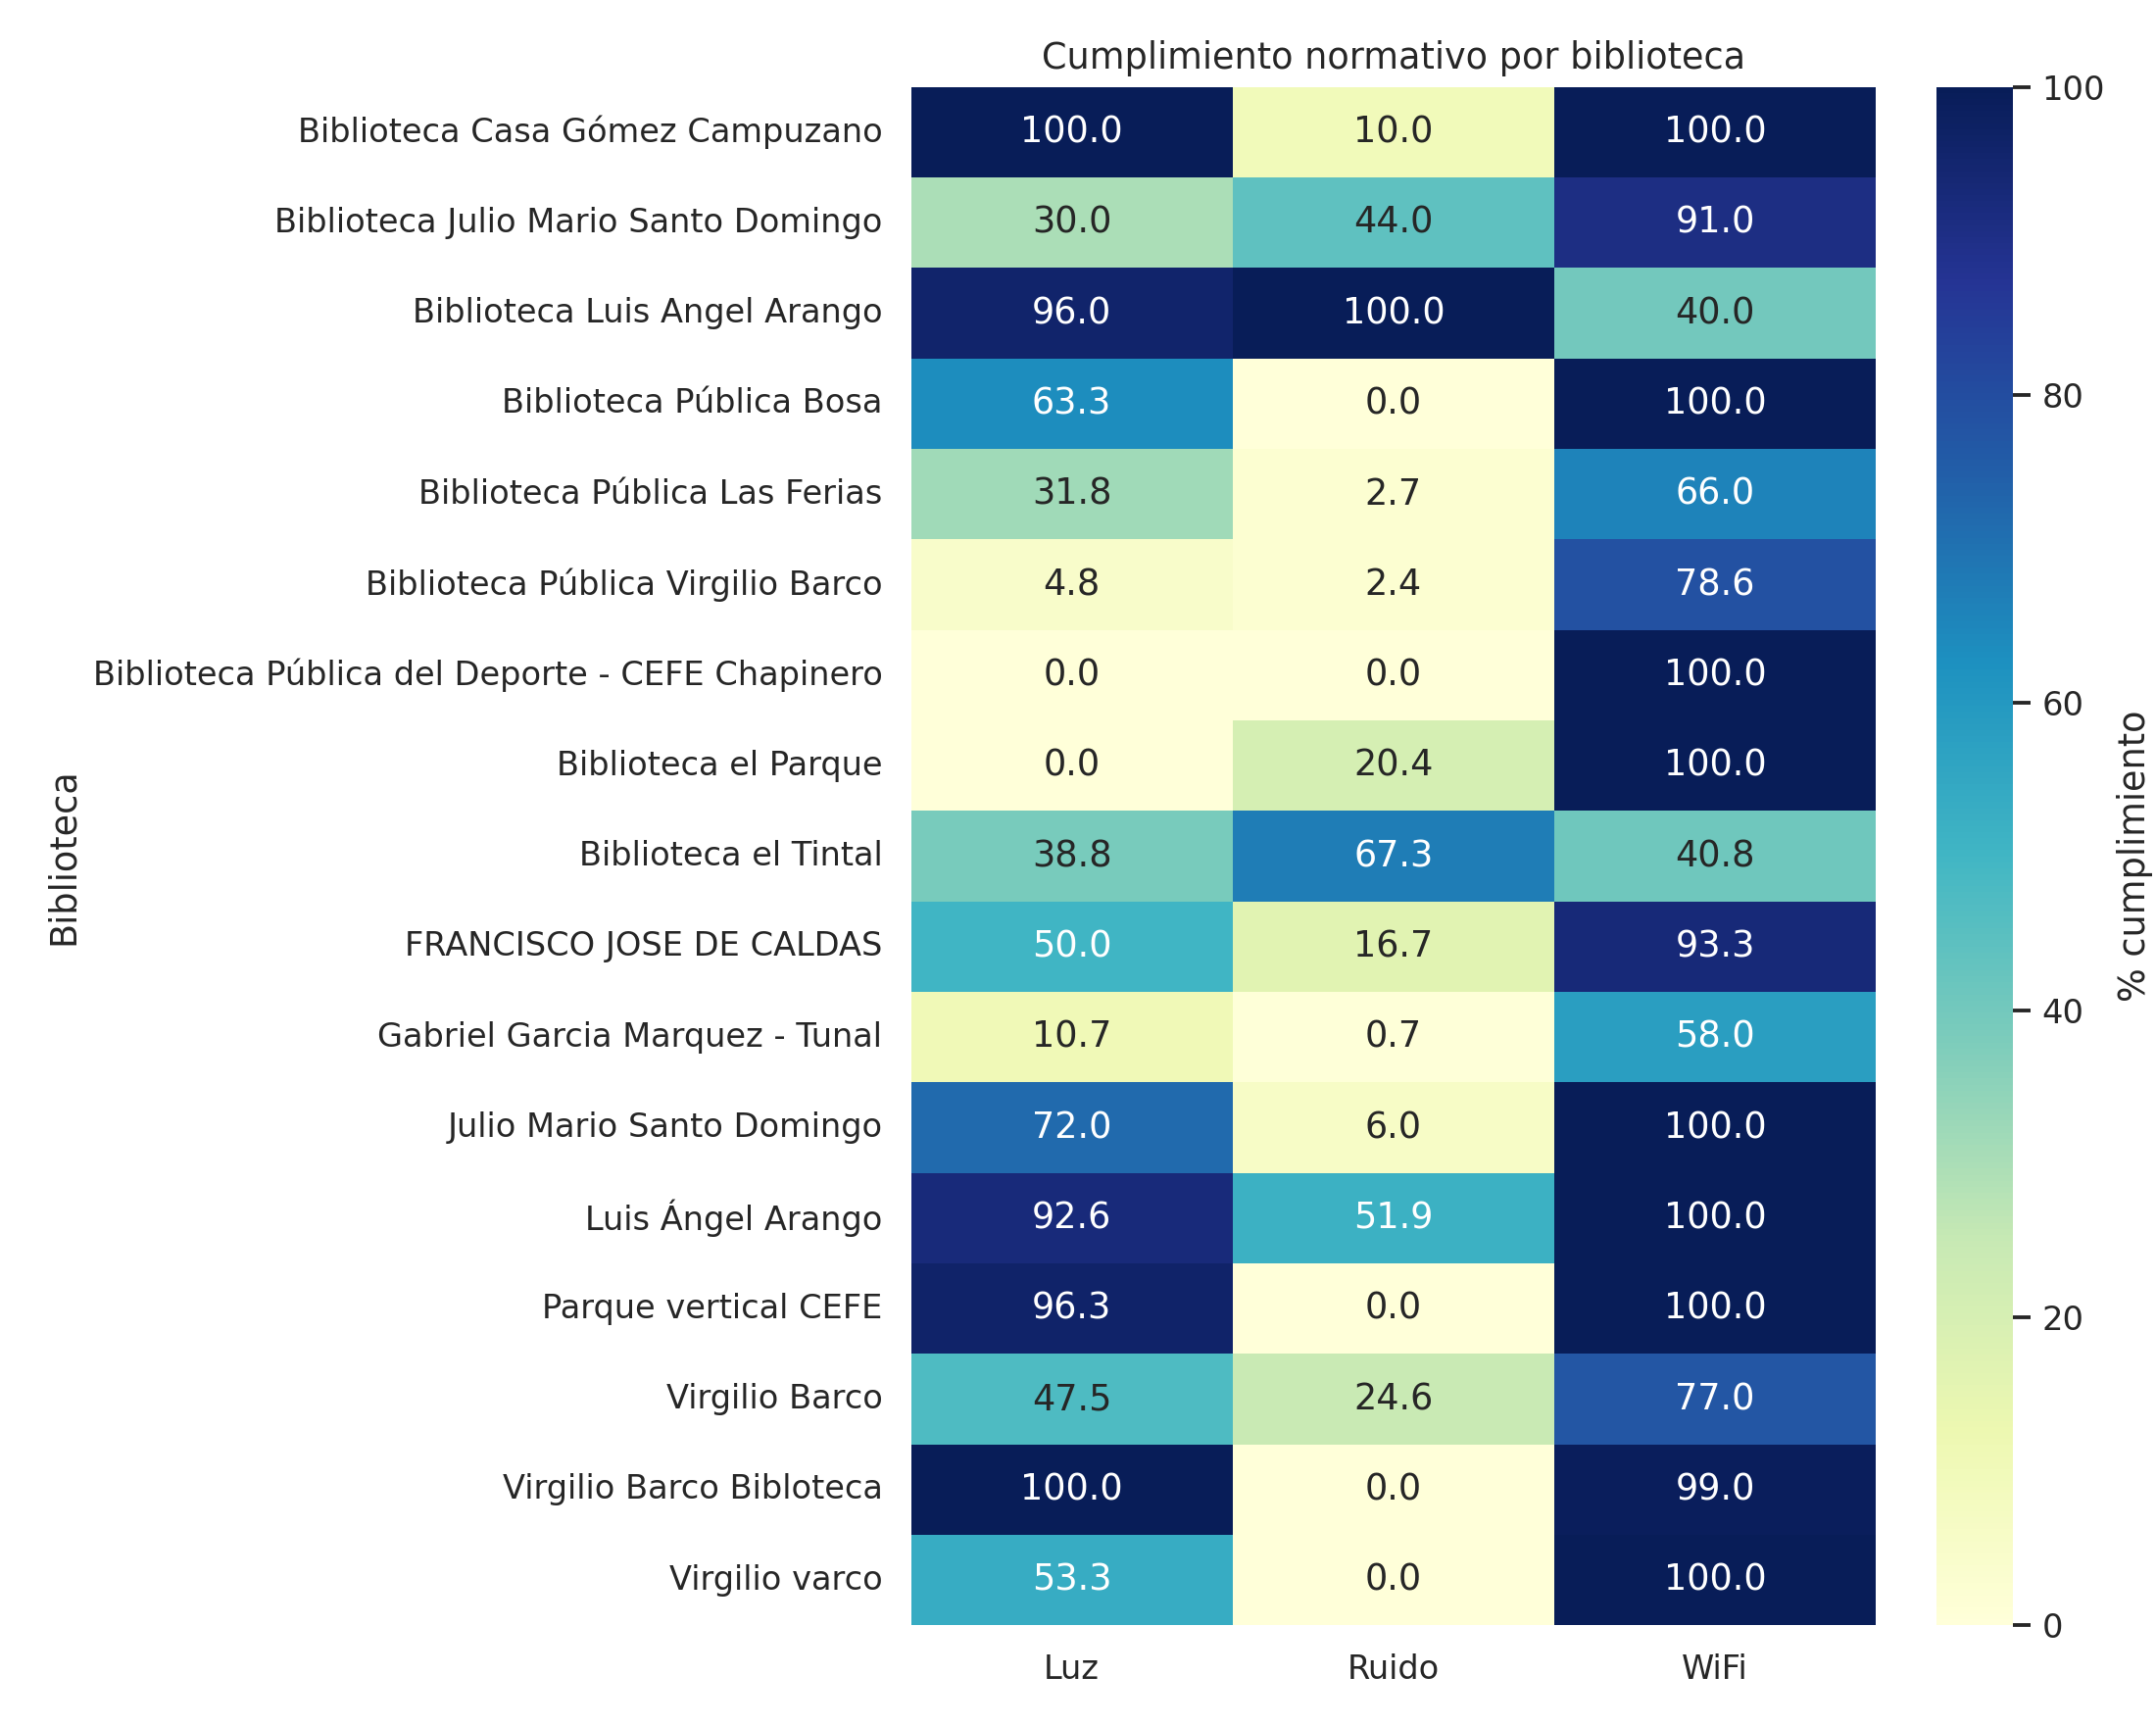

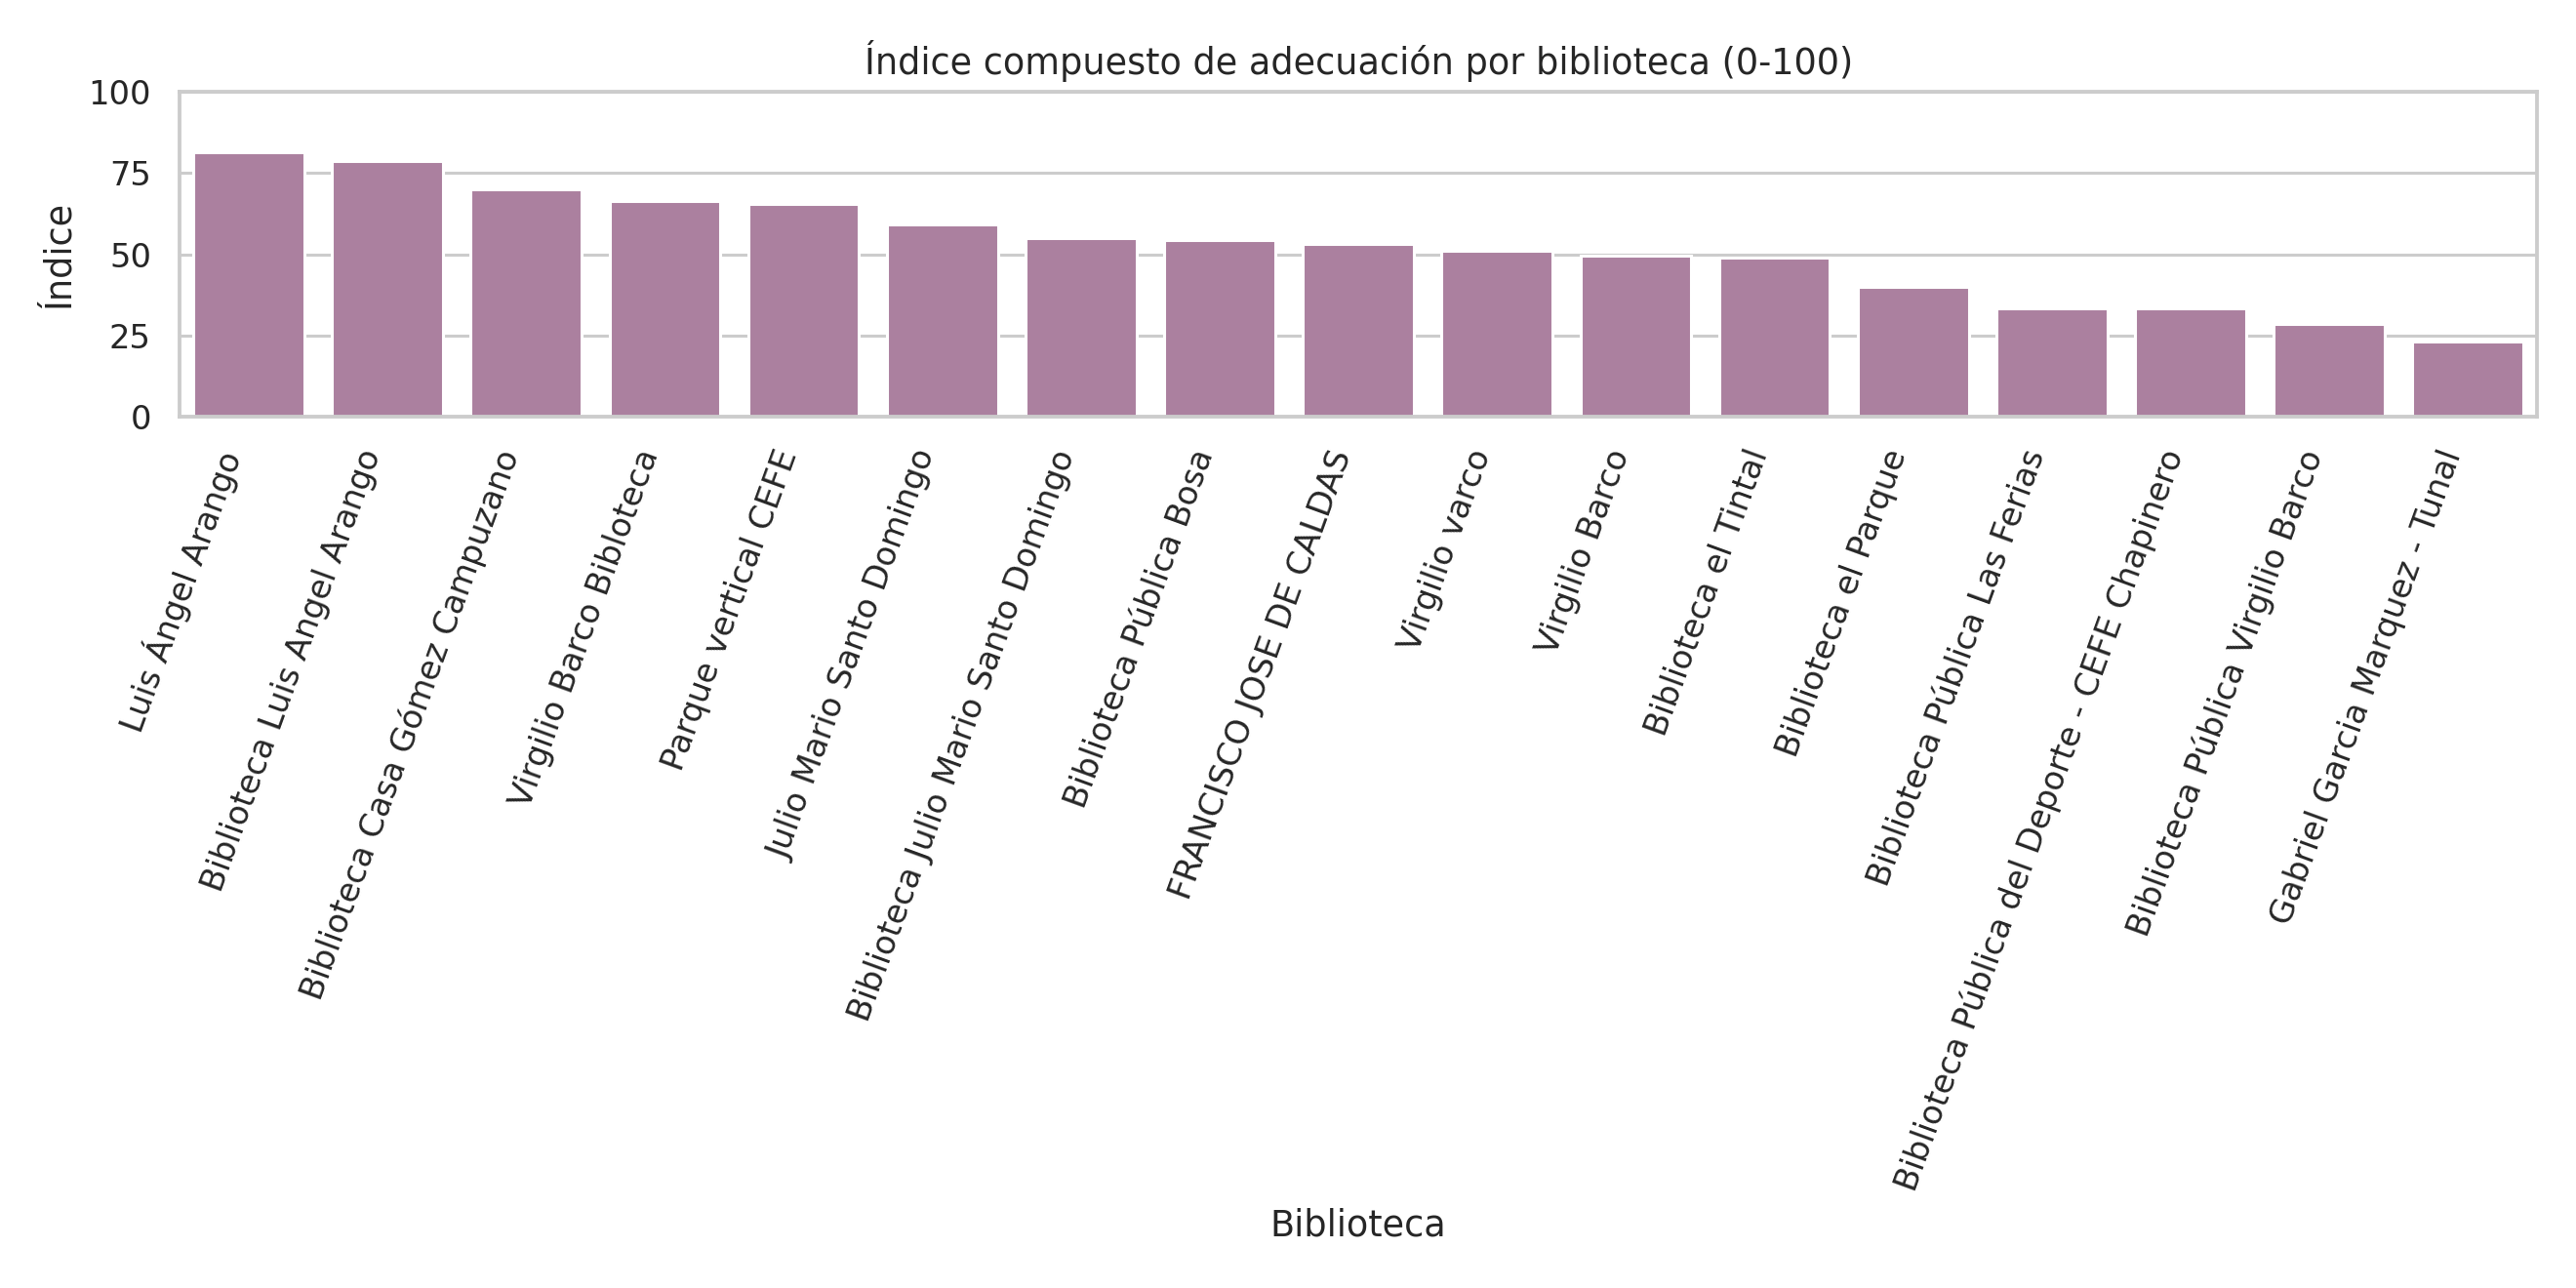

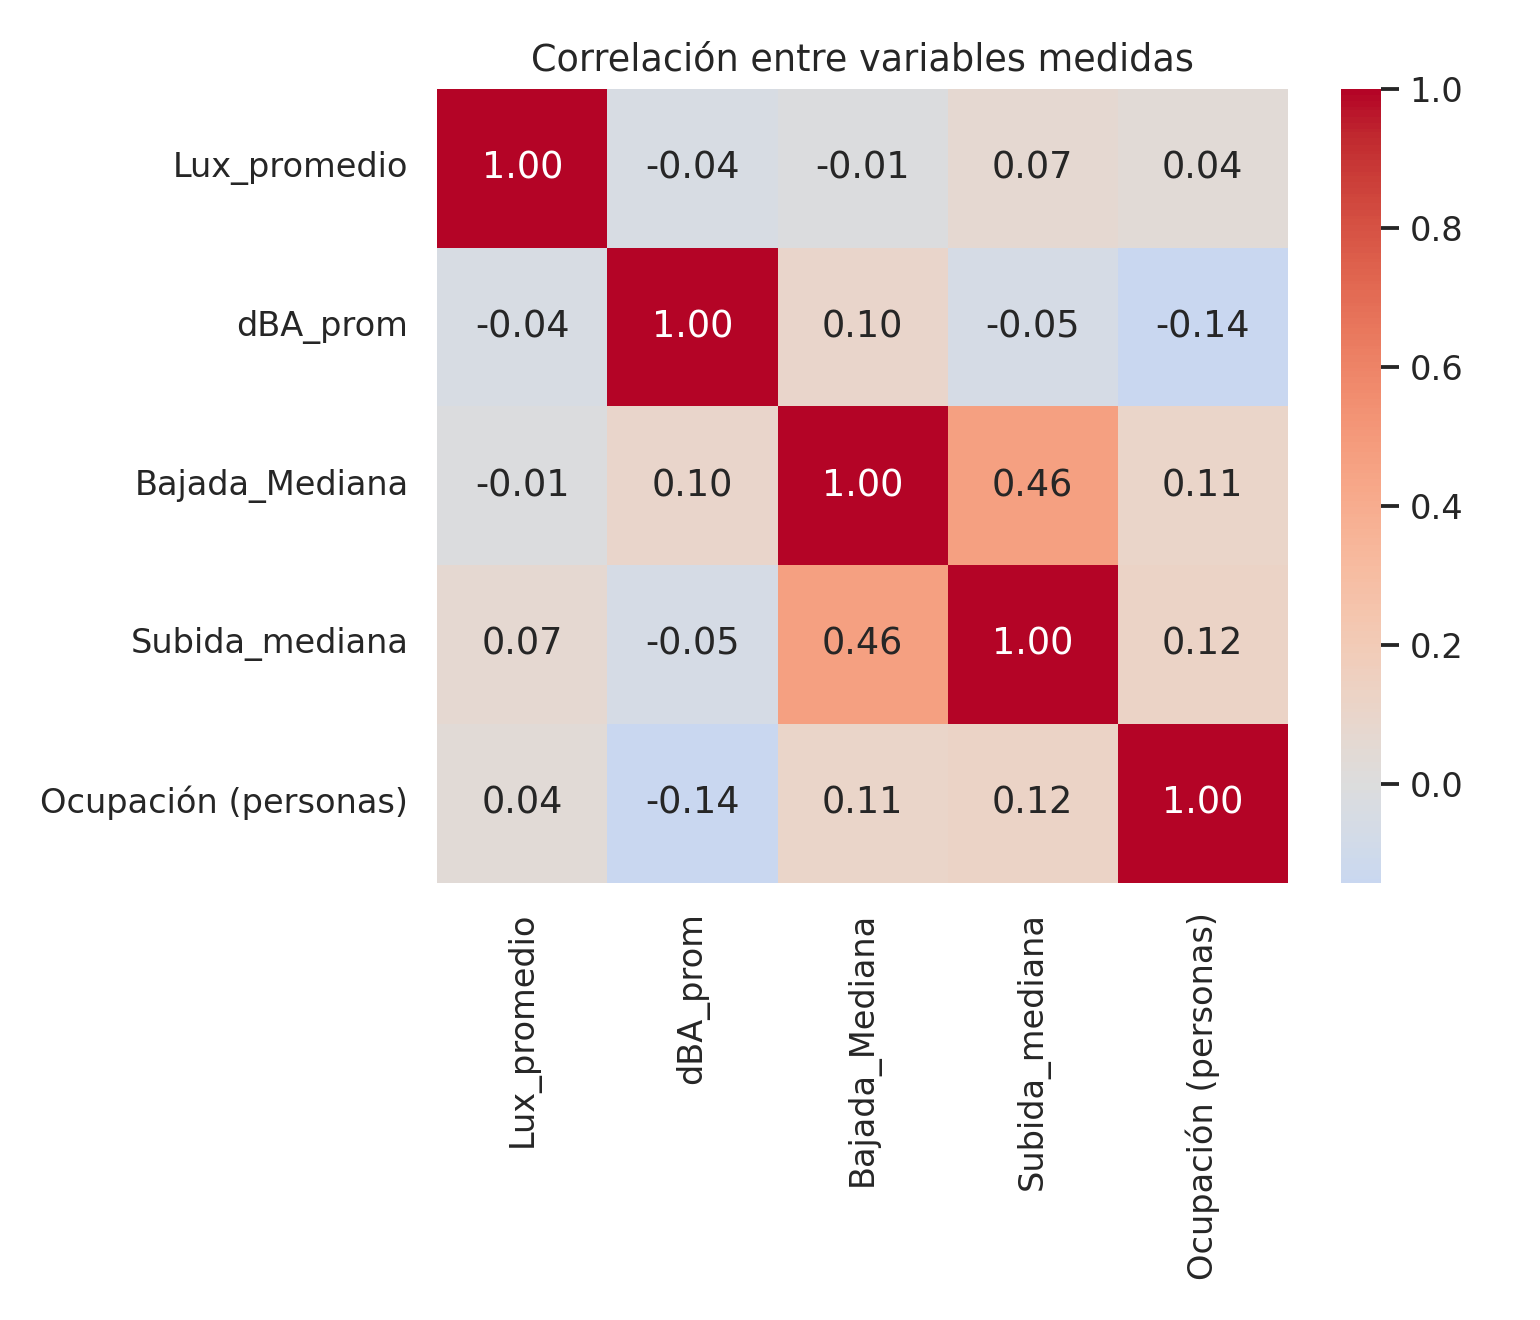

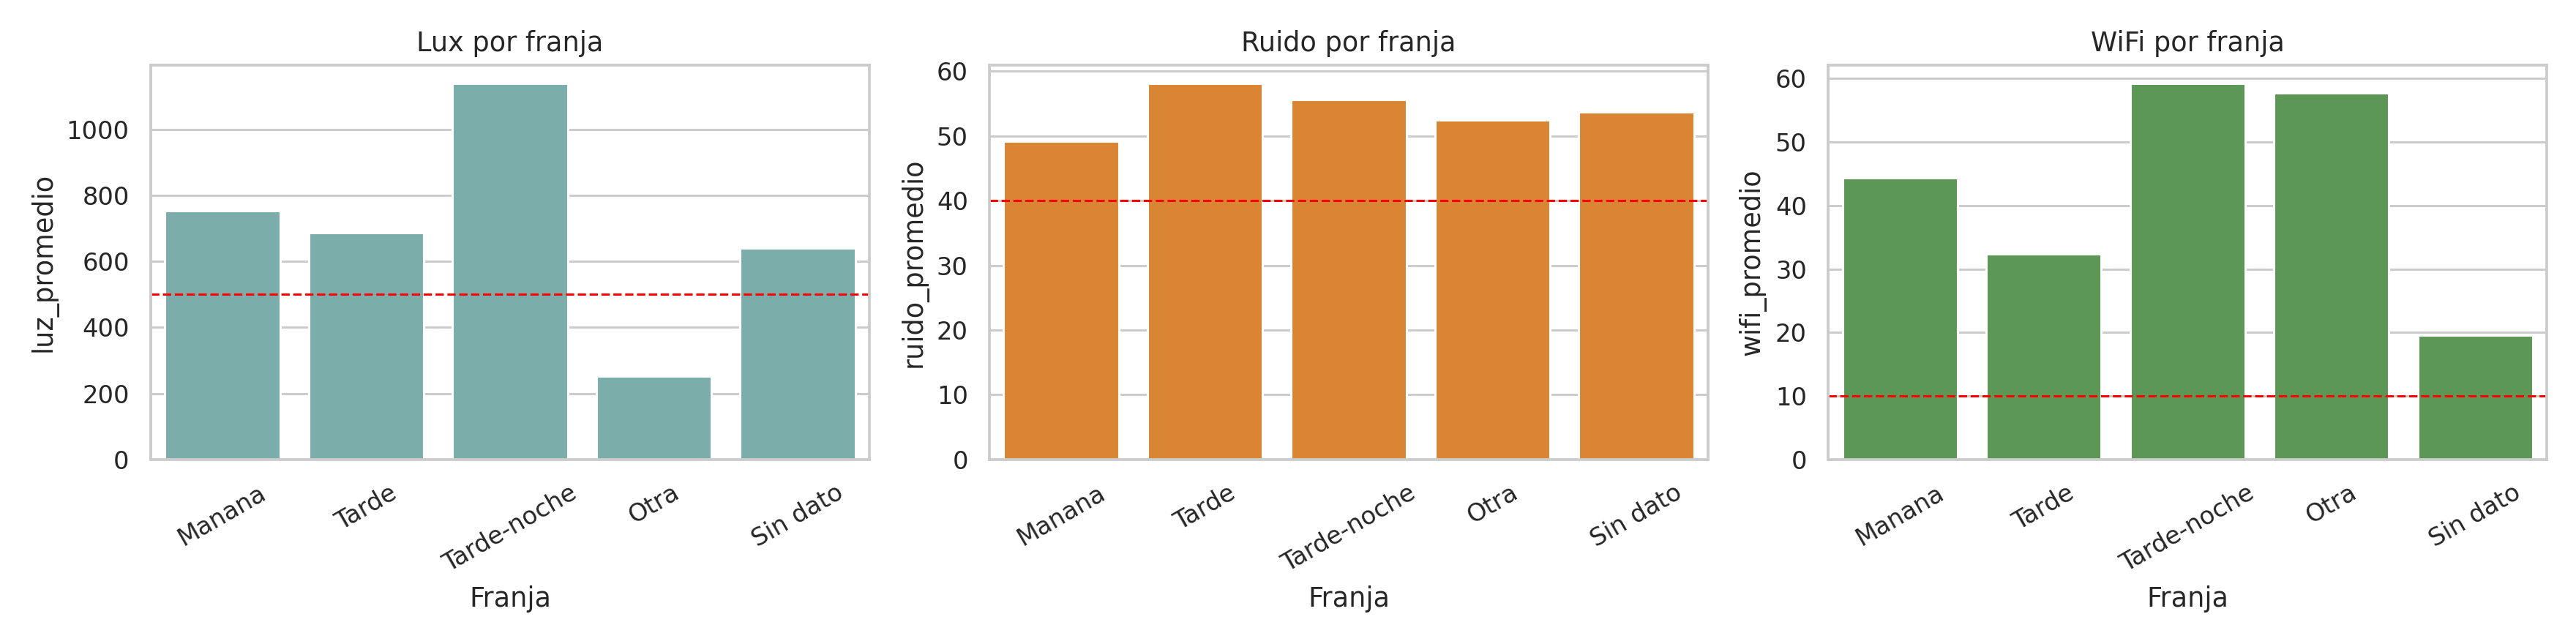

In [5]:
from IPython.display import Image, display
for fig_name in [
    "registros_por_biblioteca.png",
    "box_lux_biblioteca.png",
    "box_ruido_biblioteca.png",
    "box_wifi_biblioteca.png",
    "heatmap_cumplimiento.png",
    "indice_compuesto_biblioteca.png",
    "correlacion_metricas.png",
    "metricas_por_franja.png",
]:
    p = ROOT / "Informe" / "figuras" / fig_name
    if p.exists():
        display(Image(filename=str(p), width=900))

## 5. Visualización rápida de figuras generadas

In [6]:
from IPython.display import Image, display
for fig_name in [
    "registros_por_biblioteca.png",
    "box_lux_biblioteca.png",
    "box_ruido_biblioteca.png",
    "box_wifi_biblioteca.png",
    "heatmap_cumplimiento.png",
    "indice_compuesto_biblioteca.png",
    "correlacion_metricas.png",
    "metricas_por_franja.png",
]:
    p = BASE / "Informe" / "figuras" / fig_name
    if p.exists():
        display(Image(filename=str(p), width=900))

## 6. Guardado de resultados

Los resultados quedan en:
- `Informe/figuras/`
- `Informe/tablas/`

Estos insumos son usados directamente por `Informe/informe_calidad_bibliotecas.tex`.